Datalab Semester 2, Sprint 4

In [40]:
import os
from pathlib import Path  
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

def connect_to_database(db_filename="database.sqlite"):
    """
    Zoekt dynamisch naar het databasebestand in de huidige werkmap of bovenliggende mappen
    en zet een veilige, foutbestendige SQLite-verbinding op.
    
    Args:
        db_filename (str): De exacte naam van het SQLite-bestand. Default is 'database.sqlite'.
        
    Returns:
        sqlite3.Connection: Een actieve databaseverbinding als het bestand bestaat.
        
    Raises:
        FileNotFoundError: Als het bestand nergens in de verwachte mappenstructuur wordt gevonden.
    """
    # Bepaal de huidige map waar het notebook draait 
    current_dir = Path.cwd()
    
    possible_paths = [
        current_dir / db_filename,
        current_dir / "notebook" / db_filename,
        current_dir.parent / "notebook" / db_filename,
        current_dir.parent / db_filename
    ]
    
    target_path = None
    for path in possible_paths:
        if path.is_file():
            target_path = path
            break
            
    # Harde fail-fast check om 'unsupported file format' errors door lege bestanden te voorkomen
    if not target_path:
        print("="*60)
        print("FOUT: Databasebestand kon niet automatisch worden gevonden!")
        print("Gecontroleerde locaties:")
        for path in possible_paths:
            print(f" - {path}")
        print("="*60)
        raise FileNotFoundError(f"Kon {db_filename} nergens vinden. Controleer de bestandsnaam.")
        
    # Bestand wel gevonden: log statistieken en maak de verbinding
    file_size_mb = target_path.stat().st_size / (1024 * 1024)
    print(f"✓ Database succesvol gelokaliseerd!")
    print(f"  Pad: {target_path}")
    print(f"  Grootte: {file_size_mb:.2f} MB")
    
    # Open de database in Read-Only modus. 
    # Dit voorkomt dat SQLite stilletjes een leeg bestand aanmaakt bij een typefout.
    db_uri = f"file:{target_path}?mode=ro"
    connection = sqlite3.connect(db_uri, uri=True)
    print("✓ Succesvol verbonden met de database!")
    
    return connection

conn = connect_to_database()

✓ Database succesvol gelokaliseerd!
  Pad: c:\Users\sasha\Documents\GitHub\Datalab_semester2_Groep1\notebook\database.sqlite
  Grootte: 298.59 MB
✓ Succesvol verbonden met de database!


Opdracht 1

In [21]:
query_2 = "SELECT * FROM player_Attributes"

df_player_Attribute = pd.read_sql_query(query_2, conn)
df_player_Attribute.head(20)

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,63.0,41.0,45.0,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
5,6,189615,155782,2016-04-21 00:00:00,74.0,76.0,left,high,medium,80.0,53.0,58.0,71.0,40.0,73.0,70.0,69.0,68.0,71.0,79.0,78.0,78.0,67.0,90.0,71.0,85.0,79.0,56.0,62.0,68.0,67.0,60.0,66.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
6,7,189615,155782,2016-04-07 00:00:00,74.0,76.0,left,high,medium,80.0,53.0,58.0,71.0,32.0,73.0,70.0,69.0,68.0,71.0,79.0,78.0,78.0,67.0,90.0,71.0,85.0,79.0,56.0,60.0,68.0,67.0,60.0,66.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
7,8,189615,155782,2016-01-07 00:00:00,73.0,75.0,left,high,medium,79.0,52.0,57.0,70.0,29.0,71.0,68.0,69.0,68.0,70.0,79.0,78.0,78.0,67.0,90.0,71.0,84.0,79.0,56.0,59.0,67.0,66.0,58.0,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
8,9,189615,155782,2015-12-24 00:00:00,73.0,75.0,left,high,medium,79.0,51.0,57.0,70.0,29.0,71.0,68.0,69.0,68.0,70.0,79.0,78.0,78.0,67.0,90.0,71.0,84.0,79.0,56.0,58.0,67.0,66.0,58.0,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
9,10,189615,155782,2015-12-17 00:00:00,73.0,75.0,left,high,medium,79.0,51.0,57.0,70.0,29.0,71.0,68.0,69.0,68.0,70.0,79.0,78.0,78.0,67.0,90.0,71.0,84.0,79.0,56.0,58.0,67.0,66.0,58.0,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0


In [22]:

query_3 = "SELECT * FROM Player"

df_player = pd.read_sql_query(query_3, conn)
df_player.head(20)

,id,player_api_id,player_name,player_fifa_api_id,birthday,height,weight
0,1,505942,Aaron Appindangoye,218353,1992-02-29 00:00:00,182.88,187
1,2,155782,Aaron Cresswell,189615,1989-12-15 00:00:00,170.18,146
2,3,162549,Aaron Doran,186170,1991-05-13 00:00:00,170.18,163
3,4,30572,Aaron Galindo,140161,1982-05-08 00:00:00,182.88,198
4,5,23780,Aaron Hughes,17725,1979-11-08 00:00:00,182.88,154
5,6,27316,Aaron Hunt,158138,1986-09-04 00:00:00,182.88,161
6,7,564793,Aaron Kuhl,221280,1996-01-30 00:00:00,172.72,146
7,8,30895,Aaron Lennon,152747,1987-04-16 00:00:00,165.10,139
8,9,528212,Aaron Lennox,206592,1993-02-19 00:00:00,190.50,181
9,10,101042,Aaron Meijers,188621,1987-10-28 00:00:00,175.26,170


In [23]:
pd.set_option('display.max_columns', None)   # alle kolommen tonen
pd.set_option('display.width', None)  

df_joined = df_player_Attribute.merge(
    df_player[['player_api_id', 'player_name']],
    on='player_api_id',
    how='left'
)

cols = df_joined.columns.tolist()
cols.insert(3, cols.pop(cols.index('player_name')))  # 4e kolom = index 3
df = df_joined[cols]

df.head(30)

,id,player_fifa_api_id,player_api_id,player_name,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,Aaron Appindangoye,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,Aaron Appindangoye,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,Aaron Appindangoye,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,35.0,63.0,41.0,45.0,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,Aaron Appindangoye,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,Aaron Appindangoye,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
5,6,189615,155782,Aaron Cresswell,2016-04-21 00:00:00,74.0,76.0,left,high,medium,80.0,53.0,58.0,71.0,40.0,73.0,70.0,69.0,68.0,71.0,79.0,78.0,78.0,67.0,90.0,71.0,85.0,79.0,56.0,62.0,68.0,67.0,60.0,66.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
6,7,189615,155782,Aaron Cresswell,2016-04-07 00:00:00,74.0,76.0,left,high,medium,80.0,53.0,58.0,71.0,32.0,73.0,70.0,69.0,68.0,71.0,79.0,78.0,78.0,67.0,90.0,71.0,85.0,79.0,56.0,60.0,68.0,67.0,60.0,66.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
7,8,189615,155782,Aaron Cresswell,2016-01-07 00:00:00,73.0,75.0,left,high,medium,79.0,52.0,57.0,70.0,29.0,71.0,68.0,69.0,68.0,70.0,79.0,78.0,78.0,67.0,90.0,71.0,84.0,79.0,56.0,59.0,67.0,66.0,58.0,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
8,9,189615,155782,Aaron Cresswell,2015-12-24 00:00:00,73.0,75.0,left,high,medium,79.0,51.0,57.0,70.0,29.0,71.0,68.0,69.0,68.0,70.0,79.0,78.0,78.0,67.0,90.0,71.0,84.0,79.0,56.0,58.0,67.0,66.0,58.0,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
9,10,189615,155782,Aaron Cresswell,2015-12-17 00:00:00,73.0,75.0,left,high,medium,79.0,51.0,57.0,70.0,29.0,71.0,68.0,69.0,68.0,70.0,79.0,78.0,78.0,67.0,90.0,71.0,84.0,79.0,56.0,58.0,67.0,66.0,58.0,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0


In [24]:
# 1. Definieer de function
def get_average_player_attributes(df_attributes, df_player):
    """
    Berekent de gemiddelde statistieken per speler op basis van de Player_Attributes tabel.
    
    Args:
        df (pd.DataFrame): De originele Player_Attributes dataframe.
        
    Returns:
        pd.DataFrame: Een dataframe met unieke player_api_id's en hun gemiddelde scores.
    """

    # Kolommen filteren met list comprehension
    exclude_columns = ['id', 'player_fifa_api_id', 'player_api_id', 'date']

    # Alleen numerieke kolommen selecteren (behalve de exclude)
    relevant_cols = [
        col for col in df_attributes.columns
        if col not in exclude_columns and df_attributes[col].dtype != 'object'
    ]
    
    df_averages = (
        df_attributes
        .groupby('player_api_id')[relevant_cols]
        .mean()
        .reset_index()
    )

    # Merge met player naam
    df_merged = df_averages.merge(
        df_player[['player_api_id', 'player_name']],
        on='player_api_id',
        how='left'
    )

    # Kolomvolgorde aanpassen (player_name als 4e kolom)
    cols = df_merged.columns.tolist()
    cols.insert(1, cols.pop(cols.index('player_name')))

    return df_merged[cols]


# 2. Data ophalen uit database
player_attrs = pd.read_sql_query("SELECT * FROM Player_Attributes", conn)
df_player = pd.read_sql_query("SELECT player_api_id, player_name FROM Player", conn)


# 3. Pandas display settings (zoals jij had)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


# 4. Functie uitvoeren
df_player_stats = get_average_player_attributes(player_attrs, df_player)


# 5. Resultaat bekijken
display(df_player_stats.head(30))



,player_api_id,player_name,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,2625,"Patryk Rachwal,18",60.142857,61.142857,50.142857,47.285714,46.285714,56.500000,38.000000,54.142857,50.000000,49.928571,65.571429,59.142857,66.857143,63.285714,66.428571,49.714286,66.214286,66.714286,58.714286,77.285714,55.785714,56.857143,71.285714,62.071429,50.357143,55.285714,61.928571,62.928571,63.857143,56.571429,12.428571,12.857143,19.071429,10.357143,10.428571
1,2752,Diego Mainz,69.380952,70.380952,36.428571,37.428571,75.333333,54.809524,20.428571,44.857143,30.428571,18.857143,59.571429,55.571429,41.619048,42.190476,43.333333,60.857143,44.571429,57.428571,56.523810,60.904762,82.238095,19.571429,80.285714,71.428571,31.428571,52.428571,35.428571,71.095238,70.666667,65.571429,11.095238,6.095238,7.095238,9.095238,15.095238
2,2768,Jose Dorado,69.285714,70.571429,42.238095,42.761905,66.666667,64.714286,28.761905,40.238095,51.761905,20.047619,57.000000,56.380952,56.952381,58.904762,58.047619,69.809524,60.190476,38.761905,76.904762,59.285714,67.428571,19.428571,62.761905,74.714286,44.190476,57.761905,31.904762,71.666667,70.619048,79.714286,10.761905,15.904762,22.714286,15.142857,12.095238
3,2770,Ignacio Gonzalez,71.133333,73.533333,61.866667,67.666667,67.800000,72.533333,67.133333,75.066667,79.800000,68.666667,70.266667,76.733333,62.200000,59.800000,62.600000,65.933333,61.266667,68.333333,57.133333,51.000000,62.600000,73.000000,56.800000,44.933333,64.533333,71.600000,63.933333,30.200000,37.533333,25.000000,8.666667,15.666667,27.200000,16.333333,17.000000
4,2790,Alberto Rey,70.200000,75.800000,70.000000,37.400000,55.200000,68.000000,43.000000,60.800000,67.000000,55.400000,69.800000,66.800000,70.800000,71.200000,65.000000,69.200000,67.000000,46.400000,61.000000,70.400000,71.000000,42.400000,68.400000,63.400000,60.600000,60.000000,55.400000,74.600000,74.600000,69.000000,8.000000,17.000000,59.000000,16.600000,17.400000
5,2796,Javier Jimenez,64.600000,70.533333,17.933333,16.066667,19.733333,21.200000,16.000000,17.933333,18.533333,18.733333,19.866667,20.933333,51.866667,55.333333,59.066667,61.933333,55.533333,34.266667,79.400000,30.266667,53.000000,15.466667,27.133333,24.133333,18.533333,27.266667,21.533333,17.266667,17.933333,17.866667,73.666667,59.000000,59.866667,57.933333,69.533333
6,2802,Pablo Hernandez,76.318182,78.863636,77.181818,72.636364,55.727273,71.636364,68.272727,83.090909,80.090909,75.681818,69.590909,80.045455,81.000000,79.772727,84.272727,71.863636,75.954545,75.227273,66.090909,64.090909,53.909091,76.727273,54.545455,52.909091,74.318182,76.181818,71.363636,38.863636,43.045455,36.000000,11.863636,16.909091,23.000000,11.500000,9.954545
7,2805,Ruben Perez,72.535714,77.821429,54.392857,41.535714,53.821429,75.000000,26.321429,55.535714,56.750000,57.142857,68.857143,68.964286,67.535714,66.857143,65.500000,75.035714,69.500000,71.714286,72.642857,77.035714,75.071429,62.071429,78.214286,80.250000,57.857143,74.071429,52.107143,57.857143,76.214286,63.357143,10.107143,9.285714,18.785714,10.178571,15.535714
8,2857,Ivan Perez,65.187500,68.250000,66.750000,58.062500,47.125000,60.812500,58.000000,68.000000,65.687500,69.375000,67.875000,70.125000,66.562500,61.875000,74.000000,64.000000,80.625000,71.312500,68.375000,48.625000,58.625000,61.062500,44.562500,47.437500,60.562500,65.250000,58.500000,27.375000,34.375000,23.000000,10.687500,10.812500,25.125000,9.187500,13.250000
9,2862,Vicente Sanchez,72.911765,74.558824,68.264706,65.882353,60.000000,70.294118,69.852941,76.794118,70.617647,68.823529,64.911765,75.205882,83.558824,84.205882,87.088235,72.794118,72.352941,73.323529,81.911765,59.382353,60.911765,68.323529,49

1A

In [25]:
# 1. Definieer de function
def get_average_player_attributes(df_attributes, df_player):
    """
    Berekent de gemiddelde statistieken per speler op basis van de Player_Attributes tabel.
    
    Args:
        df (pd.DataFrame): De originele Player_Attributes dataframe.
        
    Returns:
        pd.DataFrame: Een dataframe met unieke player_api_id's en hun gemiddelde scores.
    """

    # Kolommen filteren met list comprehension
    exclude_columns = ['id', 'player_fifa_api_id', 'player_api_id', 'date']

    # Alle relevante kolomen
    relevant_cols = [
        'overall_rating',
        'volleys',
        'finishing',
        'dribbling',
        'sprint_speed',
        'ball_control',
        'acceleration',
        'stamina',
        'interceptions',
        'positioning',
        'vision',
        'gk_diving',
        'gk_handling',
        'gk_kicking',
        'gk_positioning',
        'gk_reflexes'
    ]
    
    df_averages = (
        df_attributes
        .groupby('player_api_id')[relevant_cols]
        .mean()
        .reset_index()
    )

    # Merge met player naam
    df_merged = df_averages.merge(
        df_player[['player_api_id', 'player_name']],
        on='player_api_id',
        how='left'
    )

    # Kolomvolgorde aanpassen (player_name als 4e kolom)
    cols = df_merged.columns.tolist()
    cols.insert(1, cols.pop(cols.index('player_name')))

    return df_merged[cols]


# 2. Data ophalen uit database
player_attrs = pd.read_sql_query("SELECT * FROM Player_Attributes", conn)
df_player = pd.read_sql_query("SELECT player_api_id, player_name FROM Player", conn)


# 3. Pandas display settings (zoals jij had)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


# 4. Functie uitvoeren
df_player_stats = get_average_player_attributes(player_attrs, df_player)


# 5. Resultaat bekijken
display(df_player_stats.head(10))

,player_api_id,player_name,overall_rating,volleys,finishing,dribbling,sprint_speed,ball_control,acceleration,stamina,interceptions,positioning,vision,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,2625,"Patryk Rachwal,18",60.142857,38.000000,47.285714,54.142857,63.285714,59.142857,66.857143,77.285714,62.071429,50.357143,55.285714,12.428571,12.857143,19.071429,10.357143,10.428571
1,2752,Diego Mainz,69.380952,20.428571,37.428571,44.857143,42.190476,55.571429,41.619048,60.904762,71.428571,31.428571,52.428571,11.095238,6.095238,7.095238,9.095238,15.095238
2,2768,Jose Dorado,69.285714,28.761905,42.761905,40.238095,58.904762,56.380952,56.952381,59.285714,74.714286,44.190476,57.761905,10.761905,15.904762,22.714286,15.142857,12.095238
3,2770,Ignacio Gonzalez,71.133333,67.133333,67.666667,75.066667,59.800000,76.733333,62.200000,51.000000,44.933333,64.533333,71.600000,8.666667,15.666667,27.200000,16.333333,17.000000
4,2790,Alberto Rey,70.200000,43.000000,37.400000,60.800000,71.200000,66.800000,70.800000,70.400000,63.400000,60.600000,60.000000,8.000000,17.000000,59.000000,16.600000,17.400000
5,2796,Javier Jimenez,64.600000,16.000000,16.066667,17.933333,55.333333,20.933333,51.866667,30.266667,24.133333,18.533333,27.266667,73.666667,59.000000,59.866667,57.933333,69.533333
6,2802,Pablo Hernandez,76.318182,68.272727,72.636364,83.090909,79.772727,80.045455,81.000000,64.090909,52.909091,74.318182,76.181818,11.863636,16.909091,23.000000,11.500000,9.954545
7,2805,Ruben Perez,72.535714,26.321429,41.535714,55.535714,66.857143,68.964286,67.535714,77.035714,80.250000,57.857143,74.071429,10.107143,9.285714,18.785714,10.178571,15.535714
8,2857,Ivan Perez,65.187500,58.000000,58.062500,68.000000,61.875000,70.125000,66.562500,48.625000,47.437500,60.562500,65.250000,10.687500,10.812500,25.125000,9.187500,13.250000
9,2862,Vicente Sanchez,72.911765,69.852941,65.882353,76.794118,84.205882,75.205882,83.558824,59.382353,43.264706,69.764706,70.882353,9.911765,15.676471,18.676471,11.647059,8.705882


1B

In [26]:
query_5 = "SELECT * FROM Match"

df_match = pd.read_sql_query(query_5, conn)
df_match.head(20)

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_X1,home_player_X2,home_player_X3,home_player_X4,home_player_X5,home_player_X6,home_player_X7,home_player_X8,home_player_X9,home_player_X10,home_player_X11,away_player_X1,away_player_X2,away_player_X3,away_player_X4,away_player_X5,away_player_X6,away_player_X7,away_player_X8,away_player_X9,away_player_X10,away_player_X11,home_player_Y1,home_player_Y2,home_player_Y3,home_player_Y4,home_player_Y5,home_player_Y6,home_player_Y7,home_player_Y8,home_player_Y9,home_player_Y10,home_player_Y11,away_player_Y1,away_player_Y2,away_player_Y3,away_player_Y4,away_player_Y5,away_player_Y6,away_player_Y7,away_player_Y8,away_player_Y9,away_player_Y10,away_player_Y11,home_player_1,home_player_2,home_player_3,home_player_4,home_player_5,home_player_6,home_player_7,home_player_8,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,goal,shoton,shotoff,foulcommit,card,cross,corner,possession,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,LBH,LBD,LBA,PSH,PSD,PSA,WHH,WHD,WHA,SJH,SJD,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,1.73,3.40,5.00,1.75,3.35,4.20,1.85,3.2,3.5,1.80,3.30,3.75,NaN,NaN,NaN,1.70,3.30,4.33,1.90,3.30,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,1.95,3.20,3.60,1.80,3.30,3.95,1.90,3.2,3.5,1.90,3.20,3.50,NaN,NaN,NaN,1.83,3.30,3.60,1.95,3.30,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,2.38,3.30,2.75,2.40,3.30,2.55,2.60,3.1,2.3,2.50,3.20,2.50,NaN,NaN,NaN,2.50,3.25,2.40,2.63,3.30,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,1.44,3.75,7.50,1.40,4.00,6.80,1.40,3.9,6.0,1.44,3.60,6.50,NaN,NaN,NaN,1.44,3.75,6.00,1.44,4.00,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,5.00,3.50,1.65,5.00,3.50,1.60,4.00,3.3,1.7,4.00,3.40,1.72,NaN,NaN,NaN,4.20,3.40,1.70,4.50,3.50,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67
5,6,1,1,2008/2009,1,2008-09-24 00:00:00,492478,8203,8342,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [27]:
def get_detailed_match_ratings_indexed(df_matches, df_player_stats):
    """
    Pas het match dataframe aan met gemiddelde ratings per speler.
    Zet match_api_id als index voor een professionele data-structuur.
    """
    # 1. Filter op seizoen 2015/2016 voor betrouwbare data
    df_recent = df_matches[df_matches['season'] == '2015/2016'].copy()
    df_recent = df_recent.dropna(subset=['home_player_1', 'away_player_1'])
    
    # 2. Mappings maken voor efficiënte koppeling (Eis: Principes van efficiënt coderen)
    name_map = dict(zip(df_player_stats['player_api_id'], df_player_stats['player_name']))
    rating_map = dict(zip(df_player_stats['player_api_id'], df_player_stats['overall_rating']))
    
    # 3. Speler-kolommen definiëren
    home_id_cols = [f'home_player_{i}' for i in range(1, 12)]
    away_id_cols = [f'away_player_{i}' for i in range(1, 12)]
    
    # 4. Spelergegevens toevoegen
    for col in home_id_cols + away_id_cols:
        df_recent[f'{col}_name'] = df_recent[col].map(name_map)
        df_recent[f'{col}_rating'] = df_recent[col].map(rating_map)
    
    # 5. Teamgemiddelden berekenen (Data-analyse eis)
    df_recent['home_team_rating'] = df_recent[[f'{c}_rating' for c in home_id_cols]].mean(axis=1)
    df_recent['away_team_rating'] = df_recent[[f'{c}_rating' for c in away_id_cols]].mean(axis=1)
    
    # 6. match_api_id de index maken (Jouw verzoek)
    df_recent = df_recent.set_index('match_api_id')
    
    # 7. Kolommen ordenen voor de Technisch Directeur
    match_info = ['season', 'league_id', 'home_team_api_id', 'away_team_api_id', 'home_team_goal', 'away_team_goal', 'home_team_rating', 'away_team_rating']
    player_order = []
    for i in range(1, 12):
        player_order.extend([f'home_player_{i}', f'home_player_{i}_name', f'home_player_{i}_rating'])
    for i in range(1, 12):
        player_order.extend([f'away_player_{i}', f'away_player_{i}_name', f'away_player_{i}_rating'])
        
    return df_recent[match_info + player_order]

# Uitvoeren en opslaan
df_full_analysis = get_detailed_match_ratings_indexed(df_match, df_player_stats)

# Controleer de nieuwe structuur
display(df_full_analysis.head())

,season,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_team_rating,away_team_rating,home_player_1,home_player_1_name,home_player_1_rating,home_player_2,home_player_2_name,home_player_2_rating,home_player_3,home_player_3_name,home_player_3_rating,home_player_4,home_player_4_name,home_player_4_rating,home_player_5,home_player_5_name,home_player_5_rating,home_player_6,home_player_6_name,home_player_6_rating,home_player_7,home_player_7_name,home_player_7_rating,home_player_8,home_player_8_name,home_player_8_rating,home_player_9,home_player_9_name,home_player_9_rating,home_player_10,home_player_10_name,home_player_10_rating,home_player_11,home_player_11_name,home_player_11_rating,away_player_1,away_player_1_name,away_player_1_rating,away_player_2,away_player_2_name,away_player_2_rating,away_player_3,away_player_3_name,away_player_3_rating,away_player_4,away_player_4_name,away_player_4_rating,away_player_5,away_player_5_name,away_player_5_rating,away_player_6,away_player_6_name,away_player_6_rating,away_player_7,away_player_7_name,away_player_7_rating,away_player_8,away_player_8_name,away_player_8_rating,away_player_9,away_player_9_name,away_player_9_rating,away_player_10,away_player_10_name,away_player_10_rating,away_player_11,away_player_11_name,away_player_11_rating
match_api_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1979832,2015/2016,1,9997,8342,2,1,64.768994,68.864531,242243.0,William Dutoit,68.000000,130738.0,Mamadou Bagayoko,65.400000,164323.0,Ruben Fernandes,69.687500,210392.0,Yvan Erichot,56.000000,466480.0,Faycal Rherras,64.000000,641042.0,Alfonso Artabe,60.000000,613260.0,Jean-Luc Dompe,61.416667,215415.0,Rob Schoofs,66.600000,207603.0,Yuji Ono,67.071429,466589.0,Yohan Boli,65.200000,365245.0,Edmilson Junior,69.083333,104384.0,Sebastien Bruzzese,62.952381,543969.0,Dion Cools,67.000000,445873.0,Brandon Mechele,68.764706,305132.0,Stefano Denswil,70.208333,178293.0,Laurens De Bock,67.380952,109061.0,Ruud Vormer,70.709677,113868.0,Victor Vazquez,72.225806,26440.0,Timmy Simons,74.571429,465730.0,Boli Bolingoli-Mbombo,64.500000,37069.0,Tom De Sutter,70.896552,201915.0,Abdoulaye Diaby,68.300000
1979833,2015/2016,1,8571,9985,2,1,65.651503,68.026782,206592.0,Darren Keet,67.055556,94284.0,Anthony van Loo,62.333333,156693.0,Maxime Chanot,67.214286,157375.0,Benoit Poulain,63.166667,181312.0,Zarko Tomasevic,66.600000,95614.0,Gertjan De Mets,65.360000,192326.0,Elohim Rolland,67.666667,38257.0,Nebojsa Pavlovic,67.047619,478447.0,Adam Marusic,67.454545,70959.0,Athanassios Papazoglou,68.125000,581141.0,Aboubakar Kamara,60.142857,159883.0,Yohan Thuram Ulien,68.035714,174054.0,Martin Milec,67.250000,277848.0,Dino Arslanagic,66.055556,203755.0,Alexander Scholz,70.058824,33620.0,Jelle van Damme,72.923077,34183.0,Ricardo Faty,67.454545,512033.0,Faysel Kasmi,59.000000,242719.0,Adrien Trebel,68.571429,38378.0,Jonathan Legear,69.240000,167057.0,Ivan Santini,69.545455,202562.0,Anthony Knockaert,70.160000
1979834,2015/2016,1,9987,1773,3,1,68.785264,64.785331,91929.0,Laszlo Koteles,67.850000,465750.0,Timothy Castagne,66.130435,195448.0,Kara Mbodji,73.037037,149219.0,Christian Kabasele,70.730769,166675.0,Derrick Tshimanga,68.285714,533228.0,"Onyinye Ndidi,26",62.500000,37112.0,Julien Gorius,69.192308,32863.0,Thomas Buffel,71.800000,38969.0,Yoni Buyens,68.200000,354494.0,Siebe Schrijvers,65.782609,25957.0,Igor de Camargo,73.129032,37993.0,Yves Lenaerts,63.416667,131404.0,David Vandenbroeck,63.636364,26078.0,Flavien La Postollec,64.454545,179783.0,Romain Reynaud,65.944444,419238.0,Konstantinos Rougalas,62.444444,280968.0,Yohan Croizet,66.777778,303202.0,Nicolas Delporte,64.600000,38777.0,Jordan Remacle,68.772727,105680.0,John Bostock,65.958333,409000.0,Kevin Tapoko,62.833333,197848.0,Alessandro Cerigioni,63.800000
1979835,2015/2016,1,8573,8203,3,1,67.446760,65.972988,107806.0,Didier Ovono,65.842105,95615.0,Brecht Capon,65.444444,298941.0,Antonio Milic,67.400000,30918.0,David Rozehnal,74

Toelichting Opdracht 1b: Transformatie van het Match Dataframe

In deze stap is het match dataframe uitgebreid en geherstructureerd om de kwaliteiten van de individuele spelers en de teams direct inzichtelijk te maken per wedstrijd. Dit vormt de basis voor de analyse of clubs hebben gepresteerd naar verwachting op basis van hun spelersstatistieken.  

Werking van de Code en de Ratings:
Data-integriteit & Filtering: Er is specifiek gefilterd op het seizoen 2015/2016. In eerdere seizoenen ontbraken veel speler-ID's, wat de berekening
van teamgemiddelden onbetrouwbaar zou maken. Door rijen met ontbrekende basisspelers te verwijderen, wordt een zuivere dataset gegarandeerd.

Efficiënt Coderen:
Er is gebruikgemaakt van dictionary mapping in combinatie met een loop om de data van alle 22 spelersposities tegelijkertijd te verwerken.  
List comprehensions zijn toegepast voor het dynamisch identificeren van de juiste kolommen, wat handmatige fouten voorkomt en de snelheid verhoogt.

De Rating-logica:
Individuele Rating: Per speler wordt de gemiddelde overall_rating uit opdracht 1a gebruikt. Dit cijfer vertegenwoordigt het stabiele vaardigheidsniveau van de speler voor dat seizoen.

Geavanceerde Structuur:
De match_api_id is ingesteld als de index van het dataframe voor een professionele en unieke identificatie van elke wedstrijd.
De kolommen zijn geordend in een logische volgorde voor de technisch directeur: eerst het ID, dan de Naam en tot slot de Rating van elke speler.

De resultaten zijn opgeslagen in het nieuwe dataframe df_full_analysis, waarmee voldaan wordt aan de eis dat de data-analyse wordt opgeslagen in een nieuw object voor verdere visualisatie.

1C

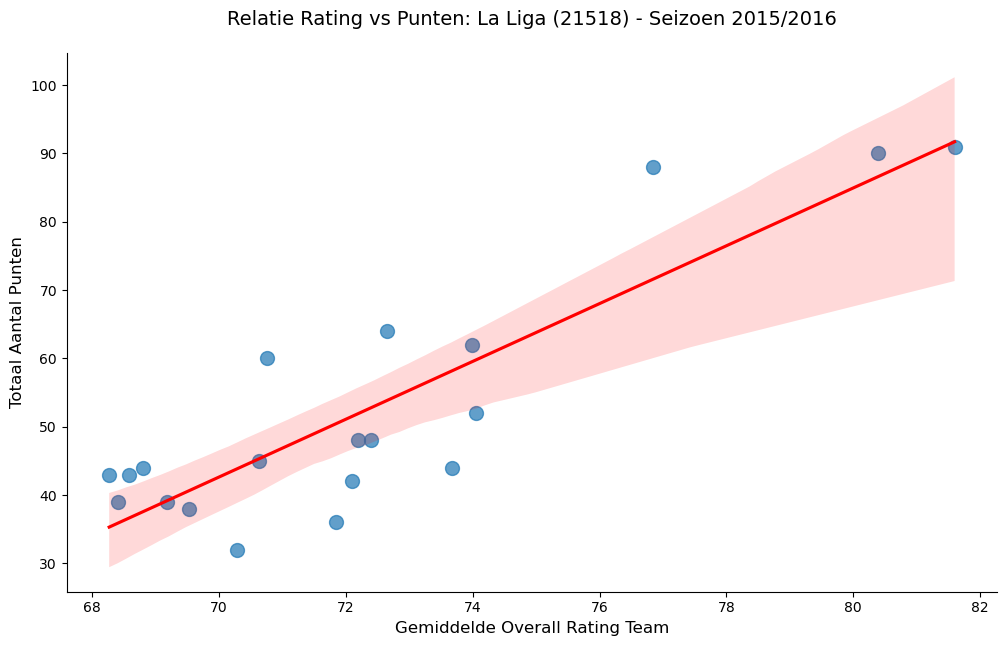

In [28]:
df_teams = pd.read_sql_query("SELECT * FROM Team", conn)
def calculate_league_stats(df_results, df_teams, target_league_id):
    """
    Berekent de seizoensstatistieken per team voor een specifieke competitie.
    Maakt gebruik van zelfgedefinieerde functies en efficiëntie-principes. 
    """
    # Filter op de gevraagde competitie (21518) 
    df_league = df_results[df_results['league_id'] == target_league_id].copy()
    
    team_stats = []
    all_teams = pd.concat([df_league['home_team_api_id'], df_league['away_team_api_id']]).unique()

    for team_id in all_teams:
        # Thuiswedstrijden: Punten en ratings 
        h_m = df_league[df_league['home_team_api_id'] == team_id]
        h_pts = h_m.apply(lambda r: 3 if r['home_team_goal'] > r['away_team_goal'] else (1 if r['home_team_goal'] == r['away_team_goal'] else 0), axis=1).sum()
        
        # Uitwedstrijden: Punten en ratings 
        a_m = df_league[df_league['away_team_api_id'] == team_id]
        a_pts = a_m.apply(lambda r: 3 if r['away_team_goal'] > r['home_team_goal'] else (1 if r['away_team_goal'] == r['home_team_goal'] else 0), axis=1).sum()
        
        # Gemiddelde rating berekenen over het hele seizoen 
        total_pts = h_pts + a_pts
       
        avg_rating = (h_m['home_team_rating'].mean() + a_m['away_team_rating'].mean()) / 2
        
        # Teamnaam ophalen 
        t_name = df_teams[df_teams['team_api_id'] == team_id]['team_long_name'].values[0]
        
        team_stats.append({'team_name': t_name, 'total_points': total_pts, 'avg_rating': avg_rating})
    
    return pd.DataFrame(team_stats)

df_league_stats = calculate_league_stats(df_full_analysis, df_teams, 21518)

def plot_team_performance_clean(df, title):
    """
    Maakt een schone visualisatie conform de gevraagde stijl:
    Geen namen, geen grid en geen top/right spines.
    """
    plt.figure(figsize=(12, 7))
    
    # Scatterplot met regressielijn
    sns.regplot(
        data=df, 
        x='avg_rating', 
        y='total_points', 
        scatter_kws={'s':100, 'alpha':0.7}, 
        line_kws={"color": "red"}
    )
    
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel('Gemiddelde Overall Rating Team', fontsize=12)
    plt.ylabel('Totaal Aantal Punten', fontsize=12)
    
    plt.grid(False)
    sns.despine()
    plt.show()

plot_team_performance_clean(df_league_stats, 'Relatie Rating vs Punten: La Liga (21518) - Seizoen 2015/2016')

Interpretatie voor de Technisch Directeur

Deze visualisatie brengt de relatie tussen de spelerskwaliteit en de daadwerkelijke competitieresultaten in kaart. Hieronder volgt de uitleg van de gebruikte elementen:

De rode lijn Dit is de regressielijn. Deze representeert de verwachte prestatie en geeft aan hoeveel punten een team gemiddeld zou moeten halen op basis van de overall rating van de spelers.

De blauwe punten Elke stip vertegenwoordigt een specifiek team uit de competitie.

De rode gloed Dit is het betrouwbaarheidsinterval. Het geeft de onzekerheidsmarge van onze voorspelling aan.

Analyse van afwijkingen Wanneer een team ver buiten deze rode gloed valt is er sprake van een statistisch significante afwijking.
 
Boven de gloed Teams die ver boven de gloed uitsteken presteren uitzonderlijk veel beter dan men op basis van de individuele spelersratings mag verwachten. Dit duidt op een hoge efficiëntie of een sterke tactiek van de trainer.

Onder de gloed Teams die ver onder de gloed vallen presteren ondermaats vergeleken met het aanwezige spelersmateriaal.

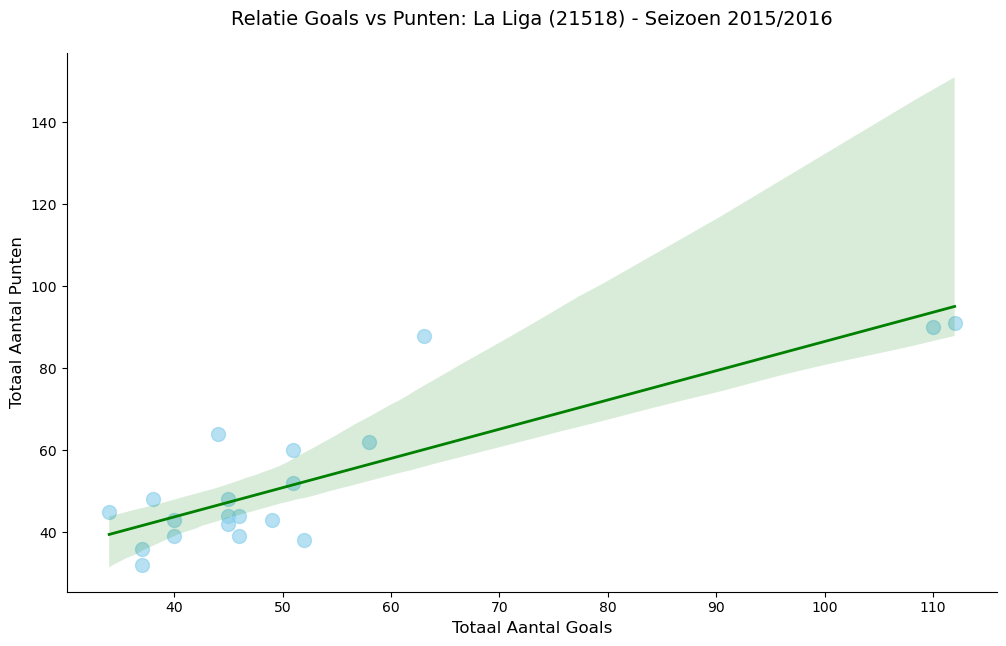

In [29]:
def calculate_league_stats_with_goals(df_results, df_teams, target_league_id):
    """
    Berekent punten, ratings en goals per team.
    """
    df_league = df_results[df_results['league_id'] == target_league_id].copy()
    team_stats = []
    all_teams = pd.concat([df_league['home_team_api_id'], df_league['away_team_api_id']]).unique()

    for team_id in all_teams:
        # Thuiswedstrijden
        h_m = df_league[df_league['home_team_api_id'] == team_id]
        h_pts = h_m.apply(lambda r: 3 if r['home_team_goal'] > r['away_team_goal'] else (1 if r['home_team_goal'] == r['away_team_goal'] else 0), axis=1).sum()
        h_goals = h_m['home_team_goal'].sum()
        
        # Uitwedstrijden
        a_m = df_league[df_league['away_team_api_id'] == team_id]
        a_pts = a_m.apply(lambda r: 3 if r['away_team_goal'] > r['home_team_goal'] else (1 if r['away_team_goal'] == r['home_team_goal'] else 0), axis=1).sum()
        a_goals = a_m['away_team_goal'].sum()
        
        total_pts = h_pts + a_pts
        total_g = h_goals + a_goals
        avg_r = (h_m['home_team_rating'].mean() + a_m['away_team_rating'].mean()) / 2
        
        t_name = df_teams[df_teams['team_api_id'] == team_id]['team_long_name'].values[0]
        team_stats.append({'team_name': t_name, 'total_points': total_pts, 'total_goals': total_g, 'avg_rating': avg_r})
    
    return pd.DataFrame(team_stats)

df_league_stats_v2 = calculate_league_stats_with_goals(df_full_analysis, df_teams, 21518)

def plot_goals_vs_points_scatter(df, title):
    """
    Maakt een scatterplot om de relatie tussen goals en punten te visualiseren.
    Inclusief regressielijn en zonder grid/boven-rechter lijnen.
    """
    plt.figure(figsize=(12, 7))
    
    sns.regplot(
        data=df, 
        x='total_goals', 
        y='total_points', 
        scatter_kws={'s':100, 'alpha':0.6, 'color': 'skyblue'}, 
        line_kws={"color": "green", "linewidth": 2}
    )
    
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel('Totaal Aantal Goals', fontsize=12)
    plt.ylabel('Totaal Aantal Punten', fontsize=12)
    
    plt.grid(False)
    sns.despine() 
    
    plt.show()

plot_goals_vs_points_scatter(df_league_stats_v2, 'Relatie Goals vs Punten: La Liga (21518) - Seizoen 2015/2016')

Interpretatie voor de Technisch Directeur

Deze visualisatie brengt de relatie tussen het scorend vermogen en de uiteindelijke competitieresultaten in kaart. Hieronder volgt de uitleg van de gebruikte elementen:

De groene lijn Dit is de regressielijn. Deze geeft aan hoeveel punten een team gemiddeld behaalt op basis van het aantal gescoorde doelpunten. De stijgende lijn bevestigt dat meer doelpunten leiden tot een hogere positie op de ranglijst.

De blauwe punten Elke stip vertegenwoordigt een specifiek team uit de competitie. De spreiding van deze punten laat zien hoe efficiënt teams zijn in het omzetten van doelpunten naar punten.

De groene gloed Dit is het betrouwbaarheidsinterval. Het toont de onzekerheidsmarge van onze voorspelling aan. We zien dat de marge groter wordt aan de rechterkant van de grafiek omdat er minder teams zijn die extreem veel scoren.

Analyse van uitschieters Teams die ver boven de groene lijn liggen zijn defensief zeer stabiel; zij hebben relatief weinig doelpunten nodig om veel punten te verzamelen. Teams onder de lijn laten ondanks hun scorend vermogen te veel punten liggen.

Conclusie voor beleid De grafiek toont een duidelijke kloof tussen de middenmoot en de absolute top die boven de 100 doelpunten scoort. Voor een Technisch Directeur onderstreept dit dat aanvallende dominantie essentieel is om mee te strijden om de bovenste plekken maar dat defensieve efficiëntie bepaalt of je boven of onder de trendlijn eindigt.

# Sprint 5


### Opdracht 1 


a. In deze opdracht wordt gebruik gemaakt van Supervised Learning. 

 

Bij Supervised Learning leert een model op basis van historische gegevens waarvan de uitkomst al bekend is. In deze dataset zijn de resultaten van voetbalwedstrijden bekend (win, draw of defeat). 

 

De sub-vorm is Classification. Het model moet namelijk voorspellen tot welke van de drie klassen een wedstrijd behoort: 

 

- win 

- draw 

- defeat 

b. Voeg het resultaat van iedere wedstrijd toe aan het match dataframe.

In [30]:
def determine_match_result(df):
    """
    Berekent vectorieel het wedstrijdresultaat voor het thuisteam.
    
    Args:
        df (pd.DataFrame): DataFrame met de kolommen 'home_team_goal' en 'away_team_goal'.
        
    Returns:
        pd.Series: Een Series met waarden 'win', 'defeat' of 'draw'.
    """
    conditions = [
        df["home_team_goal"] > df["away_team_goal"],
        df["home_team_goal"] < df["away_team_goal"]
    ]
    choices = ["win", "defeat"]
    
    return np.select(conditions, choices, default="draw")


def extract_team_match_features(df, team_id):
    """
    Verwerkt matchdata en extraheert specifieke team- en tegenstanderstatistieken.
    Pas efficiënt coderen (vectorisatie) toe in plaats van trage row-wise loops.
    
    Args:
        df (pd.DataFrame): Het getransformeerde match DataFrame.
        team_id (int): Het API ID van het specifieke team (bijv. BARCA_ID).
        
    Returns:
        pd.DataFrame: Een gefilterde kopie met berekende ratings en indicatoren.
    """
    # Filter efficiënt op thuis- óf uitwedstrijden van het team
    is_home = df["home_team_api_id"] == team_id
    is_away = df["away_team_api_id"] == team_id
    df_team = df[is_home | is_away].copy()
    
    # Herbereken de home-indicator vectorieel
    df_team["is_barca_home"] = (df_team["home_team_api_id"] == team_id).astype(int)
    
    # Vectoriële toewijzing van ratings (DRY-principe i.p.v. dubbele apply-functies)
    df_team["barca_rating"] = np.where(df_team["home_team_api_id"] == team_id, 
                                       df_team["home_team_rating"], 
                                       df_team["away_team_rating"])
    
    df_team["opponent_rating"] = np.where(df_team["home_team_api_id"] == team_id, 
                                           df_team["away_team_rating"], 
                                           df_team["home_team_rating"])
    
    # Bereken het ratingverschil
    df_team["rating_diff"] = df_team["barca_rating"] - df_team["opponent_rating"]
    
    return df_team


# 1. Voeg resultaten toe aan de hoofd-dataset
df_full_analysis["result"] = determine_match_result(df_full_analysis)
display(df_full_analysis[["home_team_goal", "away_team_goal", "result"]].head())

# 2. Extraheer specifieke data voor FC Barcelona
BARCA_ID = 8634
df_barca = extract_team_match_features(df_full_analysis, BARCA_ID)

# 3. Toon de gevraagde feature-selectie ter controle
display(df_barca[["barca_rating", "opponent_rating", "rating_diff", "is_barca_home", "result"]].head())

,home_team_goal,away_team_goal,result
match_api_id,,,
1979832,2,1,win
1979833,2,1,win
1979834,3,1,win
1979835,3,1,win
1979836,3,1,win


,barca_rating,opponent_rating,rating_diff,is_barca_home,result
match_api_id,,,,,
2030085,82.061605,73.491728,8.569877,0,defeat
2030173,79.101818,72.647529,6.454289,0,defeat
2030183,79.928112,73.554091,6.374021,1,win
2030194,81.563153,82.156086,-0.592933,0,defeat
2030205,83.397184,73.450481,9.946704,1,win


## Gekozen features

Voor het voorspellen van het wedstrijdresultaat zijn de volgende features geselecteerd:

- barca_rating
- opponent_rating
- rating_diff
- is_barca_home

### Onderbouwing

barca_rating geeft de gemiddelde kwaliteit van het Barcelona team weer.

opponent_rating geeft de gemiddelde kwaliteit van de tegenstander weer.

rating_diff geeft het verschil in kwaliteit tussen beide teams weer en is naar verwachting een sterke voorspeller van het resultaat.

is_barca_home geeft aan of Barcelona thuis speelt. In het voetbal is bekend dat thuisvoordeel invloed kan hebben op de uitslag.

### Weggelaten features

De volgende features zijn niet gebruikt:

- home_team_goal
- away_team_goal

Deze bepalen direct het resultaat van de wedstrijd en zouden datalekken veroorzaken.

Ook zijn team-ID's en speler-ID's niet gebruikt omdat deze weinig directe voorspellende waarde hebben en kunnen leiden tot overfitting.

In [31]:
class BarcaPreprocessor(BaseEstimator, TransformerMixin):
    """
    Een aangepaste scikit-learn transformer voor de pre-processing van matchdata.
    Selecteert specifiek de relevante numerieke en categorische features 
    voor het machine learning model, conform de principes van dataminimalisatie.
    """
    
    def __init__(self):
        """Initialiseert de preprocessor en definieert de te selecteren features."""
        self.feature_names = [
            "barca_rating",
            "opponent_rating",
            "rating_diff",
            "is_barca_home"
        ]

    def fit(self, X, y=None):
        """
        Fit-stap conform de scikit-learn API vereisten.
        Aangezien dit een pure selectie-transformer is, zijn er geen parameters te fitten.
        
        Args:
            X (pd.DataFrame): De input dataset.
            y (pd.Series, optioneel): De target labels.
            
        Returns:
            self: Retourneert de instantie zelf.
        """
        return self

    def transform(self, X):
        """
        Transformeert de dataset door alleen de vooraf gedefinieerde features te selecteren.
        
        Args:
            X (pd.DataFrame): De originele dataset met alle kolommen.
            
        Returns:
            pd.DataFrame: Een gefilterd DataFrame met uitsluitend de geselecteerde features.
        """
        return X[self.feature_names]



# 1. Instantieer de aangepaste preprocessor en transformeer de data
preprocessor = BarcaPreprocessor()
X = preprocessor.fit_transform(df_barca)
y = df_barca["result"]

# 2. Maak een gecombineerd DataFrame aan voor tussentijdse inspectie/analyse
df_ml = X.copy()
df_ml["result"] = y
display(df_ml.head())

# 3. Schaal alle features naar hetzelfde gemiddelde (0) en standaarddeviatie (1)
# Dit is essentieel voor algoritmen zoals Logistic Regression of SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Toon de eerste 5 rijen van de geschaalde matrix ter verificatie
print("Eerste 5 geschaalde rijen:")
print(X_scaled[:5])

# 4. Splits de data in een trainings- en testset (80% / 20%)
# De 'stratify=y' parameter garandeert dat de klassenverhouding (win/draw/defeat) 
# in beide sets identiek blijft, wat cruciaal is bij een scheve klassenbalans.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

,barca_rating,opponent_rating,rating_diff,is_barca_home,result
match_api_id,,,,,
2030085,82.061605,73.491728,8.569877,0,defeat
2030173,79.101818,72.647529,6.454289,0,defeat
2030183,79.928112,73.554091,6.374021,1,win
2030194,81.563153,82.156086,-0.592933,0,defeat
2030205,83.397184,73.450481,9.946704,1,win


Eerste 5 geschaalde rijen:
[[ 0.32759572  0.46197066 -0.31116485 -1.        ]
 [-1.75830666  0.21688649 -0.89557538 -1.        ]
 [-1.1759782   0.4800755  -0.9177485   1.        ]
 [-0.02368677  2.97737035 -2.8423015  -1.        ]
 [ 1.26884238  0.44999597  0.06917017  1.        ]]


In [32]:


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression is gekozen omdat het een eenvoudig en interpreteerbaar classificatiemodel is dat vaak als baseline wordt gebruikt.

In [33]:


lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Random Forest is gekozen omdat het complexe patronen kan herkennen en vaak goede prestaties levert bij classificatieproblemen.

In [34]:


rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [35]:


param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring="accuracy"
)

grid_lr.fit(X_train, y_train)

print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'C': 1}
0.6333333333333333


c:\Users\sasha\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


In [36]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="accuracy"
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

c:\Users\sasha\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
0.6333333333333333


In [37]:
if grid_lr.best_score_ > grid_rf.best_score_:
    best_model = grid_lr.best_estimator_
    print("Logistic Regression is het beste model")
else:
    best_model = grid_rf.best_estimator_
    print("Random Forest is het beste model")

Random Forest is het beste model


In [38]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = best_model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.875

Classification Report:
              precision    recall  f1-score   support

      defeat       0.75      1.00      0.86         3
        draw       0.00      0.00      0.00         1
         win       1.00      1.00      1.00         4

    accuracy                           0.88         8
   macro avg       0.58      0.67      0.62         8
weighted avg       0.78      0.88      0.82         8


Confusion Matrix:
[[3 0 0]
 [1 0 0]
 [0 0 4]]


c:\Users\sasha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sasha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sasha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Doelgroepgerichte Toelichting op de Model Performance (Technische Staf FC Barcelona)

Beste technische staf,

We hebben onze getrainde Machine Learning modellen (Logistic Regression en Random Forest) geoptimaliseerd met behulp van GridSearch. Op basis van de trainingsprestaties is het **Random Forest** model geselecteerd als het best presterende model om wedstrijdresultaten (winst, gelijkspel, verlies) te voorspellen. 

Hieronder volgt de toelichting op de prestaties van dit model op de onafhankelijke testset (bestaande uit 8 wedstrijden van het seizoen 2015/2016):

### 1. Algemene Nauwkeurigheid (Accuracy)
- **Resultaat**: **87.5% (0.88)**
- **Betekenis**: Het model heeft van de 8 testwedstrijden er exact 7 correct voorspeld. Dit is een zeer hoge algehele score, maar we moeten kritisch blijven vanwege de kleine testset.

### 2. Precisie (Precision) per Uitslag
Precisie geeft aan: *als het model een bepaalde uitslag voorspelt, hoe vaak klopt dit dan?*
- **Winst (Win)**: **100% (1.00)**. Als ons model voorspelt dat Barcelona wint, gebeurt dit ook daadwerkelijk. Dit geeft de technische staf maximale zekerheid bij positieve voorspellingen.
- **Verlies (Defeat)**: **75% (0.75)**. Van de voorspelde nederlagen bleek er in één geval eigenlijk sprake te zijn van een gelijkspel.
- **Gelijkspel (Draw)**: **0% (0.00)**. Het model heeft in de testset geen enkele keer een gelijkspel voorspeld.

### 3. Gevoeligheid (Recall) per Uitslag
Recall geeft aan: *hoeveel van de werkelijke uitslagen wist het model daadwerkelijk op te pikken?*
- **Winst (Win)**: **100% (1.00)**. Alle 4 de daadwerkelijke overwinningen in de testset zijn door het model correct als winst herkend.
- **Verlies (Defeat)**: **100% (1.00)**. Alle 3 de daadwerkelijke nederlagen zijn correct voorspeld.
- **Gelijkspel (Draw)**: **0% (0.00)**. De enige wedstrijd die in werkelijkheid in een gelijkspel eindigde, is door het model gemist (voorspeld als nederlaag).

### 4. F1-Score
De F1-score is het gewogen gemiddelde van Precision en Recall en geeft de algehele balans weer:
- **Winst**: **1.00** (perfect)
- **Verlies**: **0.86** (zeer sterk)
- **Gelijkspel**: **0.00** (zwak)

### 5. Foutenanalyse (Confusion Matrix)
De confusion matrix toont exact de verdeling van de voorspellingen:
- **3 wedstrijden** correct voorspeld als Verlies.
- **4 wedstrijden** correct voorspeld als Winst.
- **1 wedstrijd** die feitelijk een Gelijkspel was, werd door het model foutief voorspeld als Verlies.

### Advies en Knelpunt voor de Staf:
Hoewel een nauwkeurigheid van 87.5% uitstekend oogt, heeft het model een blind spot voor gelijke spelen. Dit komt door de data-schaarsheid in onze training: we hebben gefilterd op slechts een seizoen (2015/2016), waardoor het model met te weinig voorbeelden van gelijke spelen is getraind. Om dit model betrouwbaarder in te zetten bij wedstrijdvoorbereidingen, adviseren we om data van meerdere seizoenen toe te voegen om het model robuuster te maken.


Opdracht 2  

 In dit project wordt met persoonsdata gewerkt. Dit vraagt om zorgvuldigheid. Inventariseer welke data over de spelers worden verzameld. Leg uit wat de zes beginselen uit de AVG inhouden en bespreek hoe en in welke mate elk van de beginselen van toepassing is op de opdracht die jullie voor de Technisch Directeur hebben uitgevoerd. Geef daarnaast aan in welke risico-categorie van de AI-act deze opdracht valt en onderbouw je keuze.   

Het gaat om direct identificeerbare persoonsdata (naam, geboortedatum) én om indirecte persoonsdata (numerieke prestatiescores gekoppeld aan een uniek ID). Beide vallen onder de AVG. 

De zes beginselen van de AVG 

1. Rechtmatigheid, behoorlijkheid en transparantie 

Verwerking moet een geldige rechtsgrond hebben, eerlijk zijn tegenover de betrokkene, en duidelijk zijn over het doel. 

Toepassing: De data in het notebook zijn afkomstig uit de European Soccer Database (Kaggle), oorspronkelijk gebaseerd op FIFA-data. De spelers zijn er zelf nooit expliciet mee akkoord gegaan dat hun biometrische gegevens en prestatiesscores worden gebruikt voor analyses ten behoeve van een Technisch Directeur. De rechtsgrond is onduidelijk: er is geen toestemming van de spelers zelf, en een beroep op een gerechtvaardigd belang is twijfelachtig zonder aanwijsbare noodzaak. De beginselen van transparantie en behoorlijkheid worden hiermee onvoldoende gewaarborgd. 

2. Doelbinding 

Data mogen alleen worden verzameld voor een welbepaald, uitdrukkelijk omschreven en gerechtvaardigd doel, en mogen niet verder worden verwerkt op een manier die onverenigbaar is met dat oorspronkelijke doel. 

Toepassing: De data zijn vermoedelijk oorspronkelijk verzameld voor spelersregistratie in de context van de FIFA-videogame. Het gebruik voor scouting- en aankoopanalyses door een echte Technisch Directeur is een ander doel dan waarvoor de data zijn aangemaakt. Dit vormt een potentieel knelpunt: het hergebruik voor sport analytische beslissingen over individuele spelers vereist een afzonderlijke rechtvaardiging. 

3. Minimale gegevensverwerking (dataminimalisatie) 

Er mogen niet meer gegevens worden verwerkt dan noodzakelijk voor het doel. 

Toepassing: In het notebook worden in opdracht 1A bewust alleen relevante kolommen geselecteerd (overall_rating, finishing, stamina, gk_reflexes, etc.) en worden identificatoren zoals player_fifa_api_id en datum buiten de gemiddelden gehouden. Dat is een goede aanzet tot dataminimalisatie. Toch worden de spelersnamen nog steeds meegenomen in het eindresultaat (df_player_stats), terwijl een geanonimiseerde analyse mogelijk voldoende zou zijn geweest voor de aggregaatanalyse op teamniveau. 

4. Juistheid 

Persoonsgegevens moeten feitelijk juist zijn en waar nodig worden bijgewerkt. 

Toepassing: De ratings zijn tijdsgebonden: per speler bestaan meerdere datumstempels. Het notebook berekent een gemiddelde over alle tijdstippen, ook als die ver uit elkaar liggen (sommige records dateren van 2007). Het gebruik van zulke verouderde data in een advies aan een Technisch Directeur kan een vertekend beeld geven van de actuele kwaliteit van een speler, wat het beginsel van juistheid onder druk zet. Gefilterd wordt wel op seizoen 2015/2016 voor de wedstrijdanalyse. 

 

5. Opslagbeperking 

Gegevens mogen niet langer worden bewaard dan noodzakelijk voor het doel. 

Toepassing: Het notebook bevat geen beleid over hoe lang de data worden bewaard na de analyse. In een productiescenario zou moeten worden vastgelegd of de database met spelersnamen na afronding van het advies wordt verwijderd of geanonimiseerd. Zonder zo'n beleid is dit beginsel niet geborgd.  

6. Integriteit en vertrouwelijkheid (beveiliging) 

Gegevens moeten worden beschermd tegen onbevoegde toegang, verlies of vernietiging. 

Toepassing: Er was geen zichtbare beveiligingsmaatregelen (encryptie, toegangscontrole, logging). Alle data staan in een openbaar domein. Dit beginsel is in de huidige opzet onvoldoende geborgd. 

Risicoclassificatie onder de AI-Act 

Categorie: Hoog risico 

De opdracht valt onder de categorie hoog-risico AI-systemen zoals omschreven in Bijlage III van de EU AI-Act: systemen die worden ingezet voor het beoordelen van natuurlijke personen in een arbeidscontext, inclusief het beoordelen van prestaties, het ondersteunen van beslissingen over werving of arbeidsvoorwaarden, en het profileren van individuen. 

Het systeem berekent per speler een samengesteld prestatiegetal (gemiddelde overall rating op basis van tientallen attributen) en koppelt dit aan wedstrijdresultaten om aanbevelingen te doen aan een Technisch Directeur over aankoopbeleid. Dit raakt direct aan de professionele loopbaan en arbeidsmarktpositie van individuele voetballers: een speler die door het model als "onderpresteren" wordt beoordeeld, of wiens team ver buiten de regressieband valt, kan daardoor kansen missen of juist worden aangetrokken. Dat zijn consequenties die het werkende leven van betrokkenen beïnvloeden. 

Bovendien worden er geautomatiseerde scores gegenereerd die als input dienen voor beslissingen over mensen, zonder dat de betrokken spelers hiervan op de hoogte zijn of hier invloed op hebben. De combinatie van profilering, arbeidscontext en gebrek aan transparantie naar de betrokkenen maakt dit een hoog-risico toepassing die onder de AI-Act strengere eisen kent: denk aan verplichte risicobeheersystemen, transparantiedocumentatie, menselijk toezicht en het bijhouden van een technische documentatie. 